# Sentiment analýza twitter datasetu


In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"RT @\w+:", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.lower()

def get_hashtags(text):
    return re.findall(r"#(\w+)", str(text).lower())

def get_mentions(text):
    return re.findall(r"@(\w+)", str(text).lower())

def plot_top_items(data_dict, title, ax, color):
    if not data_dict:
        return
    items, counts = zip(*data_dict.most_common(10))
    sns.barplot(x=list(counts), y=list(items), hue=list(items), legend=False, ax=ax, palette=color)
    ax.set_title(title)
    ax.set_xlabel('Počet tweetů')

df = pd.read_csv('Sentiment.csv')
relevant_columns = ['candidate', 'text', 'sentiment', 'subject_matter', 'tweet_created', 'tweet_location', 'user_timezone']
cols_present = [c for c in relevant_columns if c in df.columns]
df = df[cols_present].copy()

df['clean_text'] = df['text'].apply(clean_text)
df['hashtags'] = df['text'].apply(get_hashtags)
df['mentions'] = df['text'].apply(get_mentions)

sia = SentimentIntensityAnalyzer()
df['vader_score'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

stop_words = set(stopwords.words('english'))
additional_stops = {'gop', 'debate', 'gopdebate', 'candidate', 'president'}
stop_words.update(additional_stops)

df['tokens'] = df['clean_text'].apply(word_tokenize)
df['tokens_filtered'] = df['tokens'].apply(lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 2])
all_words_global = sum(df['tokens_filtered'].tolist(), [])
all_hashtags_global = sum(df['hashtags'].tolist(), [])
all_mentions_global = sum(df['mentions'].tolist(), [])

freq_words_global = nltk.FreqDist(all_words_global)
freq_hashtags_global = nltk.FreqDist(all_hashtags_global)
freq_mentions_global = nltk.FreqDist(all_mentions_global)

if 'tweet_created' in df.columns:
    df['tweet_created'] = pd.to_datetime(df['tweet_created'], errors='coerce')
else:
    df['tweet_created'] = pd.NaT
    
df['tweet_hour'] = df['tweet_created'].dt.hour
df['tweet_weekday'] = df['tweet_created'].dt.day_name()

if 'tweet_location' not in df.columns:
    df['tweet_location'] = None
if 'user_timezone' not in df.columns:
    df['user_timezone'] = None


================================================ GLOBÁLNÍ STATISTIKY VŠECH KANDIDÁTŮ ================================================


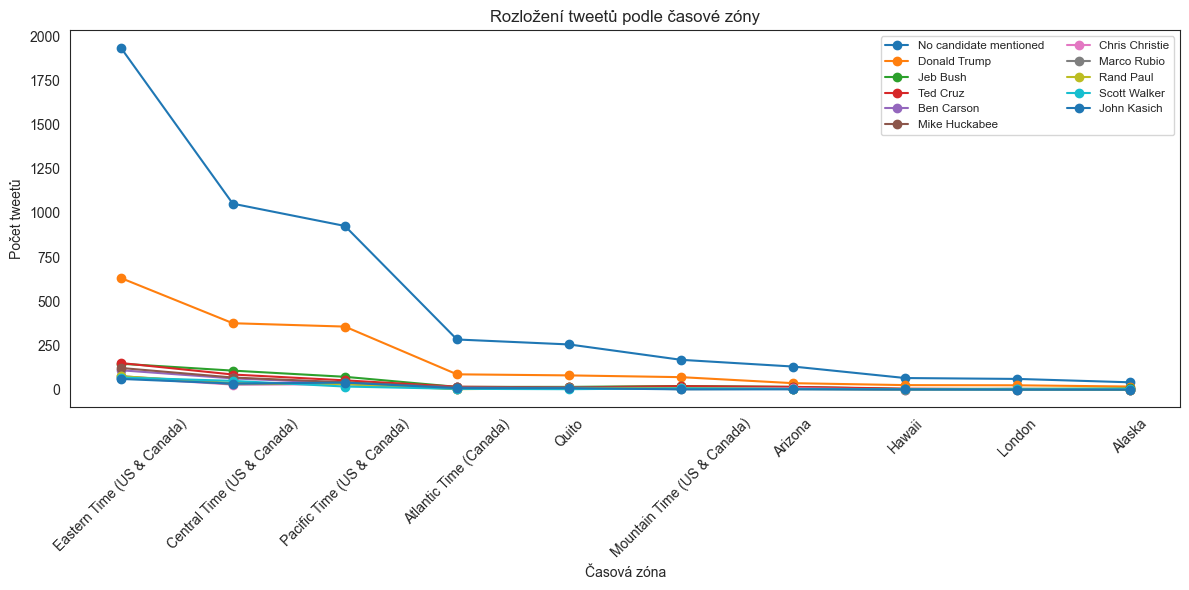

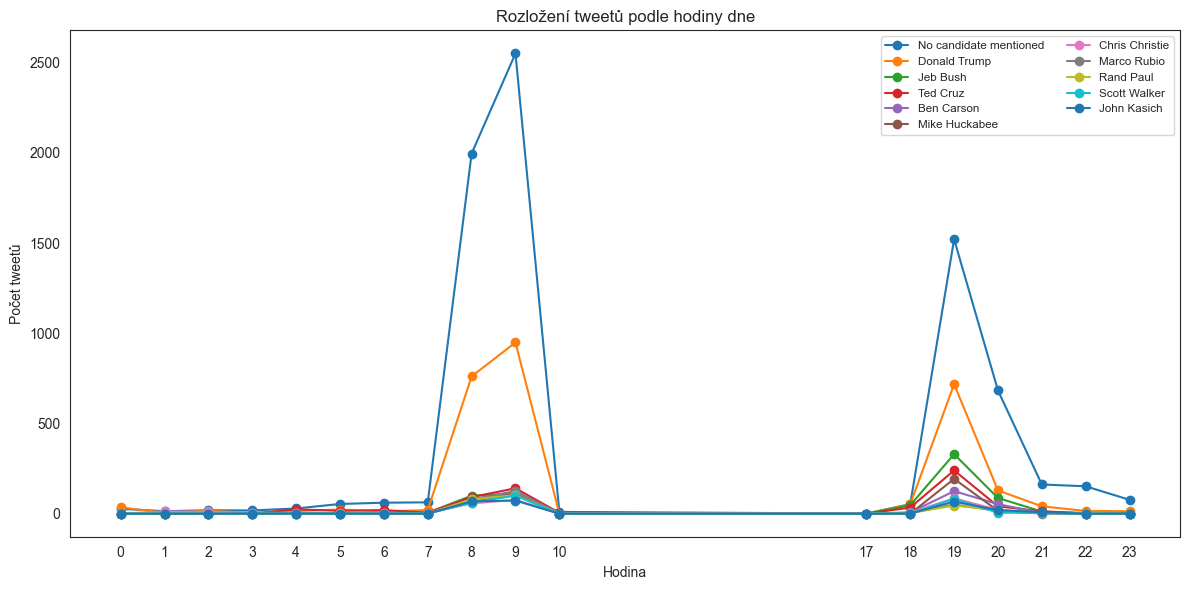

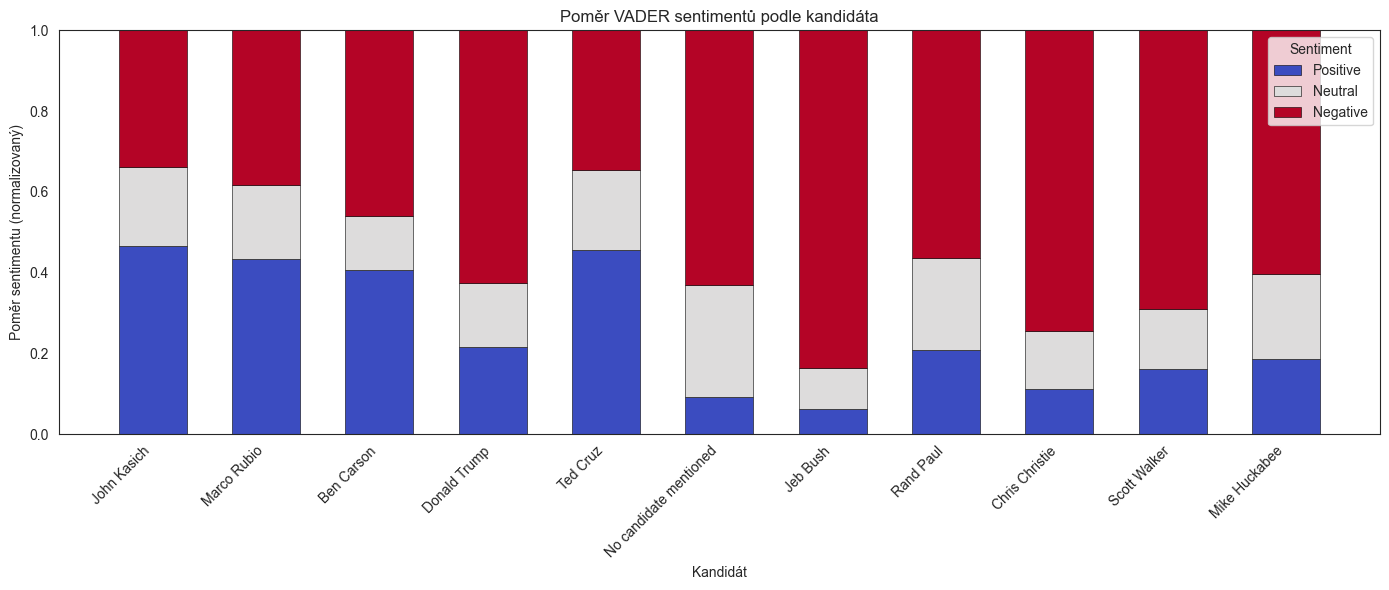

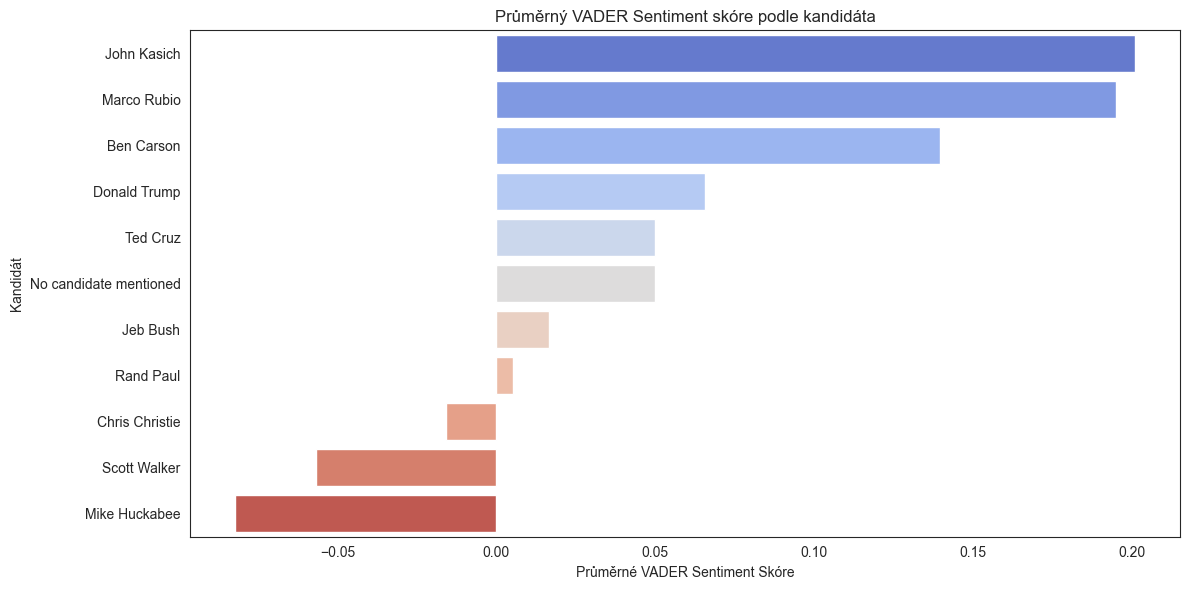

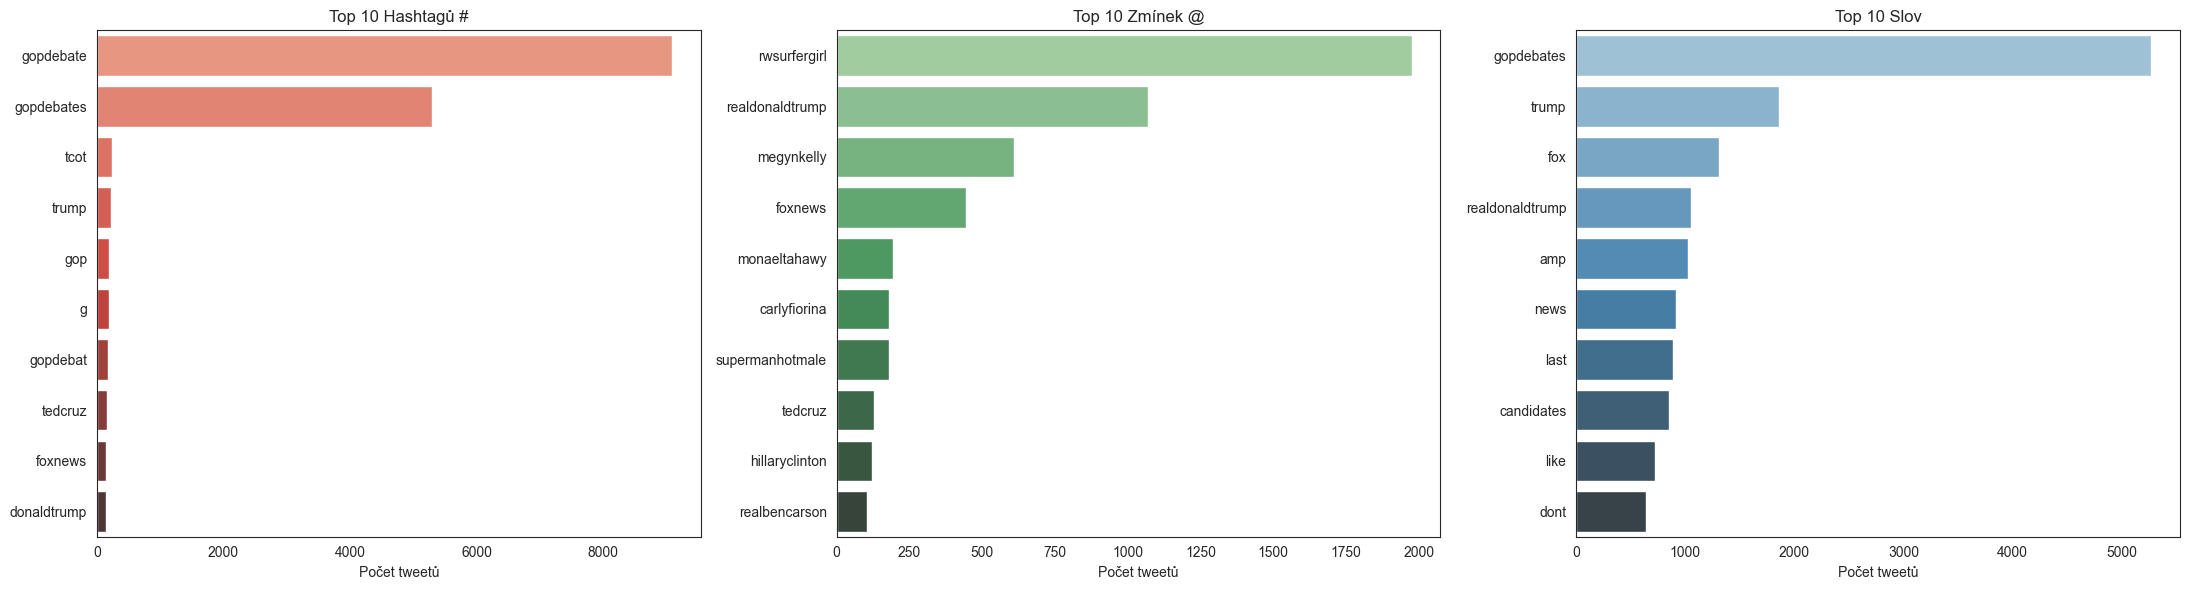

In [10]:
print(f"{'='*48} GLOBÁLNÍ STATISTIKY VŠECH KANDIDÁTŮ {'='*48}")

all_candidates = df['candidate'].dropna().unique().tolist()
counts = df['candidate'].value_counts()
candidates_to_process = counts.index.tolist()
tz_top = df[df['candidate'].isin(candidates_to_process)]['user_timezone'].dropna().astype(str).value_counts().nlargest(10).index.tolist()
tz_pivot = df[df['candidate'].isin(candidates_to_process) & df['user_timezone'].notna()].groupby(['user_timezone','candidate']).size().unstack(fill_value=0)
tz_plot_df = tz_pivot.reindex(tz_top).fillna(0)
cols = [c for c in candidates_to_process if c in tz_plot_df.columns]

if cols:
    tz_plot_df = tz_plot_df[cols]

sns.set_style('white')

if not tz_plot_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    for c in tz_plot_df.columns:
        ax.plot(tz_plot_df.index, tz_plot_df[c], marker='o', label=c)
    ax.set_title('Rozložení tweetů podle časové zóny')
    ax.set_xlabel('Časová zóna')
    ax.set_ylabel('Počet tweetů')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(ncol=2, fontsize='small')
    plt.tight_layout()
    plt.show()

hour_pivot = df[df['candidate'].isin(candidates_to_process) & df['tweet_hour'].notna()].groupby(['tweet_hour','candidate']).size().unstack(fill_value=0).sort_index()
cols = [c for c in candidates_to_process if c in hour_pivot.columns]

if cols:
    hour_pivot = hour_pivot[cols]

if not hour_pivot.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    for c in hour_pivot.columns:
        ax.plot(hour_pivot.index, hour_pivot[c], marker='o', label=c)
    ax.set_title('Rozložení tweetů podle hodiny dne')
    ax.set_xlabel('Hodina')
    ax.set_ylabel('Počet tweetů')
    ax.set_xticks(hour_pivot.index)
    ax.set_xticklabels([str(int(x)) for x in hour_pivot.index])
    ax.legend(ncol=2, fontsize='small')
    plt.tight_layout()
    plt.show()

if 'sentiment' in df.columns and df['sentiment'].notna().any():
    svals = df['sentiment'].astype(str).str.lower()
    svals = svals.replace({'pozitivni':'positive','pozitivní':'positive','negativni':'negative','negativní':'negative','neutrální':'neutral','neutral':'neutral','pos':'positive','neg':'negative','neu':'neutral'})
    df['_vader_sent'] = svals
else:
    df['_vader_sent'] = df['vader_score'].apply(lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral'))

sent_counts = df.groupby(['candidate','_vader_sent']).size().unstack(fill_value=0)

for s in ['positive','neutral','negative']:
    if s not in sent_counts.columns:
        sent_counts[s] = 0

sent_counts = sent_counts[['positive','neutral','negative']]
prop = sent_counts.div(sent_counts.sum(axis=1).replace(0,1), axis=0).fillna(0)
prop = prop.loc[(prop.sum(axis=1) > 0)]

mean_sentiments = df.groupby('candidate')['vader_score'].mean().sort_values(ascending=False)
prop = prop.reindex(mean_sentiments.index).fillna(0)

cmap = plt.get_cmap('coolwarm')
colors = [mpl.colors.to_hex(cmap(0.0)), mpl.colors.to_hex(cmap(0.5)), mpl.colors.to_hex(cmap(1.0))]
fig, ax = plt.subplots(figsize=(14, 6))
indices = np.arange(len(prop))
bottom = np.zeros(len(prop))
width = 0.6

for i, col in enumerate(prop.columns):
    ax.bar(indices, prop[col].values, bottom=bottom, color=colors[i], label=col.capitalize(), width=width, edgecolor='k', linewidth=0.4)
    bottom += prop[col].values

ax.set_xticks(indices)
ax.set_xticklabels(prop.index, rotation=45, ha='right')
ax.set_xlabel('Kandidát')
ax.set_ylabel('Poměr sentimentu (normalizovaný)')
ax.set_ylim(0, 1)
ax.set_title('Poměr VADER sentimentů podle kandidáta')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=mean_sentiments.values, y=mean_sentiments.index, hue=mean_sentiments.index, legend=False, palette='coolwarm', ax=ax)
ax.set_title('Průměrný VADER Sentiment skóre podle kandidáta')
ax.set_xlabel('Průměrné VADER Sentiment Skóre')
ax.set_ylabel('Kandidát')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
plot_top_items(freq_hashtags_global, 'Top 10 Hashtagů #', axes[0], 'Reds_d')
plot_top_items(freq_mentions_global, 'Top 10 Zmínek @', axes[1], 'Greens_d')
plot_top_items(freq_words_global, 'Top 10 Slov', axes[2], 'Blues_d')
plt.tight_layout()
plt.show()
counts_df = counts.reset_index()



================================================ ANALÝZA KANDIDÁTA: No candidate mentioned ================================================


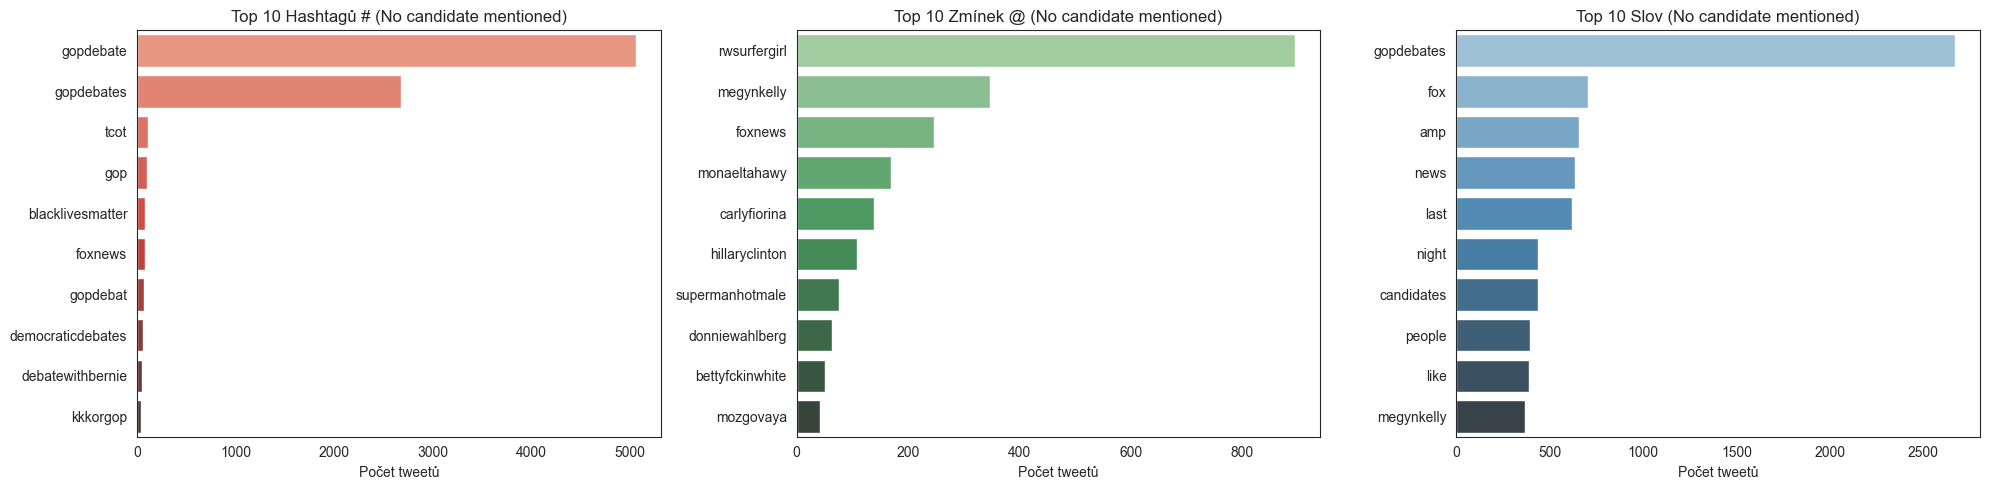


Concordance pro 'gopdebates':
- ...friend fox news corner world **gopdebates** biggest winnersand losers latins think...
- ...women talk gone open mic **gopdebates** biggest winnersand losers wonder megynkelly...
- ...topprog left always tells afraid **gopdebates** biggest winnersand losers latins think...

Concordance pro 'fox':
- ...planned parenthood women vine dabulldawg **fox** news trying convince young black...
- ...famous political assassin congratulations megynkelly **fox** news primary voters none wiser...
- ...rush limbaugh showi lost respect **fox** news **fox**news huh half clintons...

Concordance pro 'amp':
- ...worst heres question hell women **amp** body parts even foh stop...
- ...last night goodbye megynkelly bretbaier **amp** chris wallace made first donation...
- ...like megyn kellys interview style **amp** great series minute opportunities avoid...

Kolokace
fox news; chris wallace; last night; influence makeup; last nights;
united states; trying influence; obvio

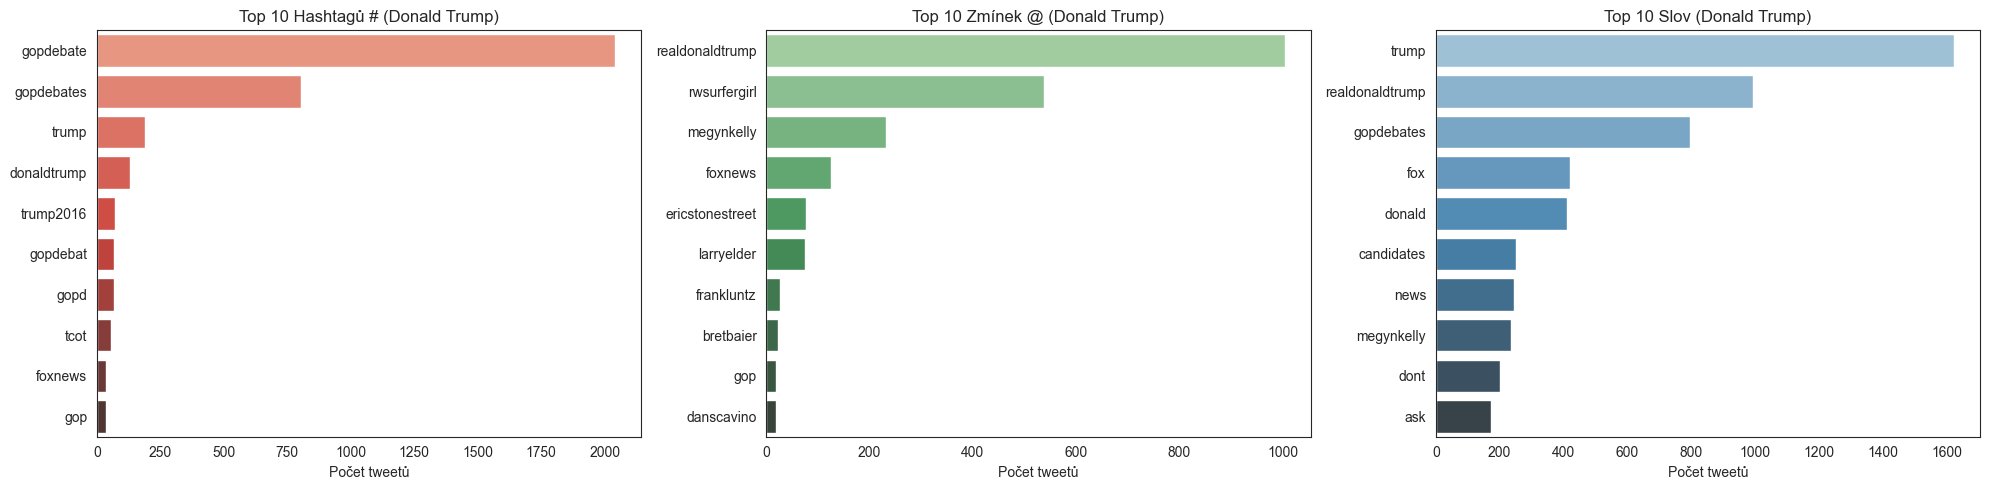


Concordance pro 'trump':
- ...highest ratings history presidential debates **trump** jgreendc realdonald**trump** fairness billclinton owns...
- ...clown show glad head clown **trump** helping destroy teatraitors still clown...
- ...clown show glad head clown **trump** helping destroy **trump** cross shrug...

Concordance pro 'realdonaldtrump':
- ...**realdonaldtrump** delivered highest ratings history presidential...
- ...history presidential debates trump jgreendc **realdonaldtrump** fairness billclinton owns phrasegopdebate donaldtrump...
- ...spy nonfarmpayrolls jobs netflix danscavino **realdonaldtrump** delivered highest ratings history presidential...

Concordance pro 'gopdebates':
- ...saw rising sun theatres yesterdays **gopdebates** change mind impressed disappointed donald...
- ...news youre raising realdonaldtrump ratings **gopdebates** trump got ask questions attacks...
- ...pledge support establishment sold obama **gopdebates** heaven help new pres bernie...

===========

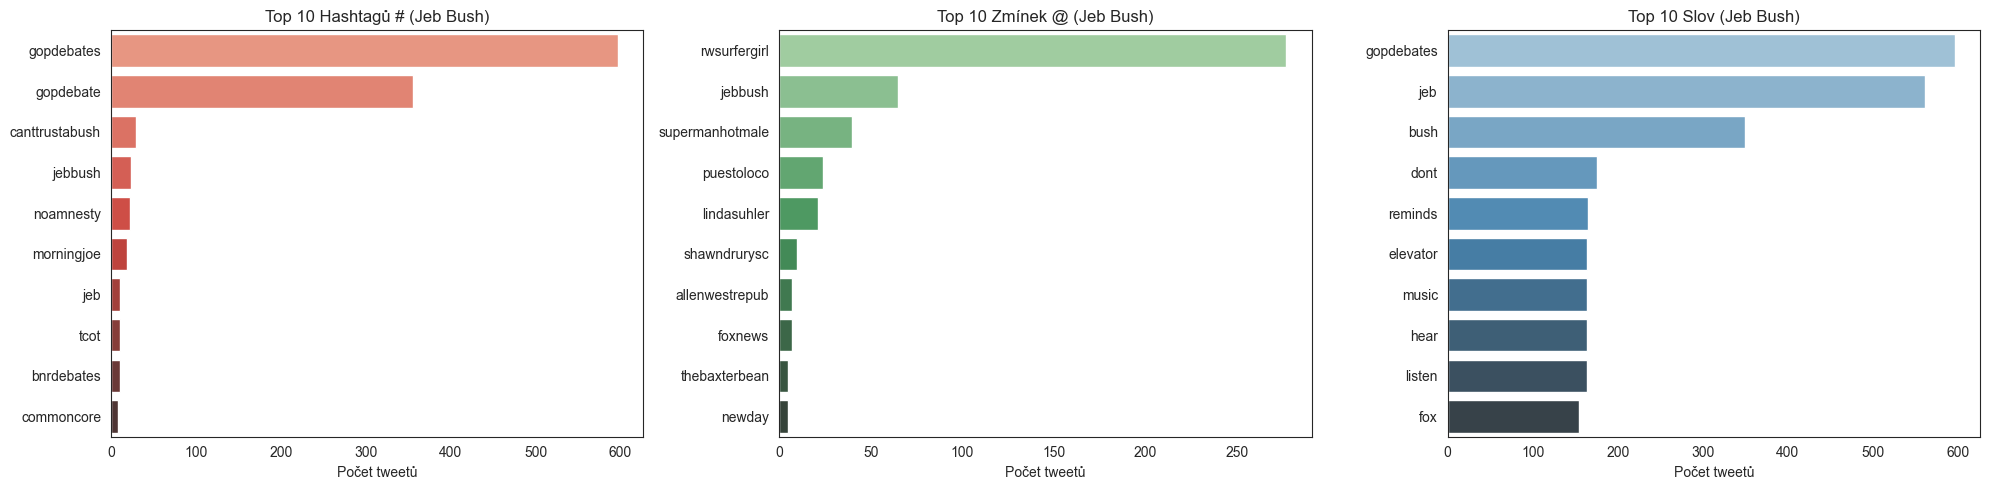


Concordance pro 'gopdebates':
- ...trying influence makeup republican field **gopdebates** hadiyah jen bush looks like...
- ...earned legal status boo noamnesty **gopdebates** fox cherry picking candidates jeb...
- ...candidates jeb gets softball questions **gopdebates** **gopdebates** strong showing carlyfiorina jeb...

Concordance pro 'jeb':
- ...allenwestrepub dear **jeb**bush notamistake **jeb** bush obama fault brother obama...
- ...challenging teachers unions beating way **jeb** **jeb**bush thoughtful rethink lot jobs...
- ...serves terms conservatives committed suicide **jeb** giving serious janet reno tonight...

Concordance pro 'bush':
- ...allenwestrepub dear jeb**bush** notamistake jeb **bush** obama fault brother obama didnt...
- ...thoughtful rethink lot jobs available **bush** serves terms conservatives committed suicide...
- ...kids disenfranchise ones teach jeb **bush** defunded planned parenthood proud denied...

================================================ ANALÝZ

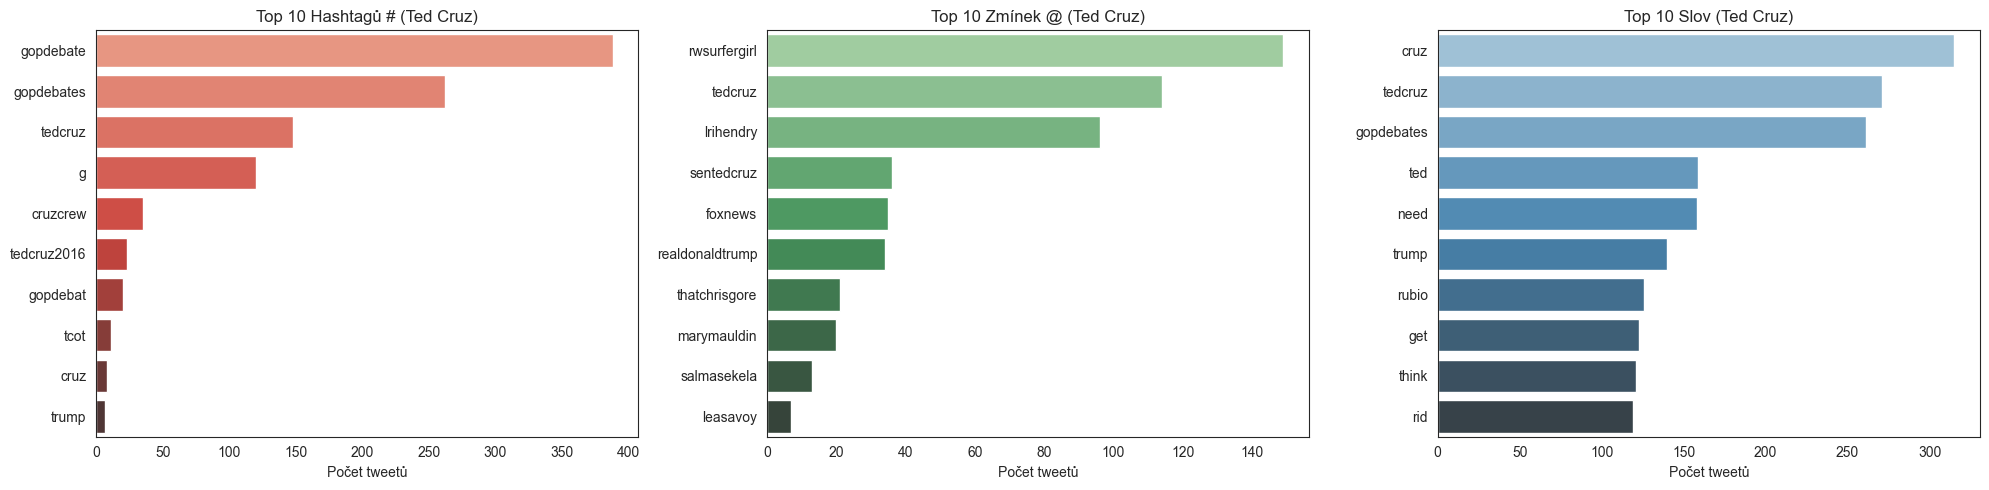


Concordance pro 'cruz':
- ...action taken barack obama foxnews **cruz** class amp truth gets vote...
- ...amp truth gets vote ted **cruz** like ted **cruz** bed keep...
- ...vote ted **cruz** like ted **cruz** bed keep confusingly sad look...

Concordance pro 'tedcruz':
- ...**tedcruz** first day rescind every illegal...
- ...isis sign death warrant signed **tedcruz** next wakeupamerica cruzcrew htt elected...
- ...support running mate pot thank **tedcruz** speaking govermentcartel makeamericagreatagain securetheborder really...

Concordance pro 'gopdebates':
- ...eyebrows dont trust wakeupamerica fox **gopdebates** freezes tedcruz minutes fair tcot...
- ...minutes fair tcot wakeupamerica fox **gopdebates** freezes tedcruz minutes fair tcot...
- ...minutes fair tcot wakeupamerica fox **gopdebates** freezes tedcruz minutes fair tcot...

================================================ ANALÝZA KANDIDÁTA: Ben Carson ================================================


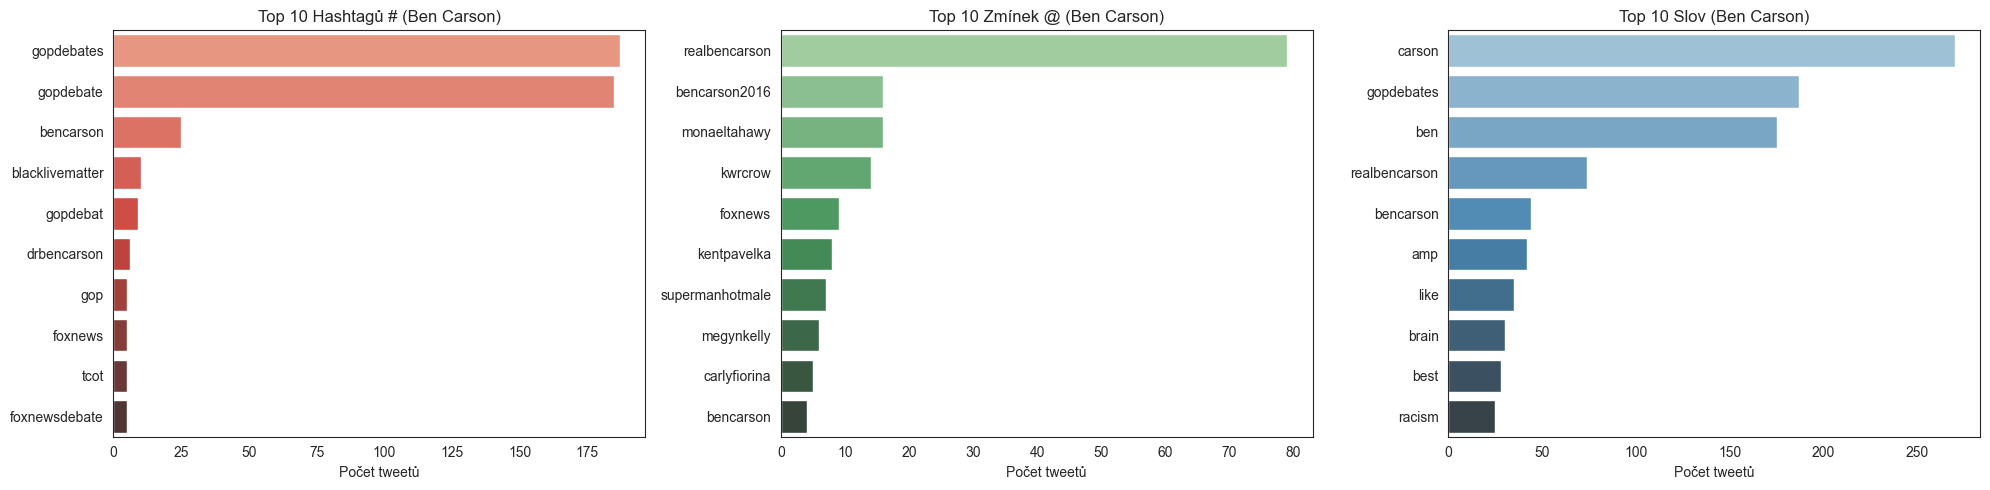


Concordance pro 'carson':
- ...deer headlights ben **carson** may brain surgeon performed lobotomy...
- ...brain surgeon performed lobotomy ben **carson** spoke science neiltyson like think...
- ...gods pretty fair guy ben **carson** neurosurgeon belief modern day taxation...

Concordance pro 'gopdebates':
- ...next carly fiorina youre wrong **gopdebates** tcot someone tell ben carson...
- ...barely let speak racism much **gopdebates** foxnews says realbencarson topped candidates...
- ...topped candidates new twitter followers **gopdebates** place foxnews says realbencarson topped...

Concordance pro 'ben':
- ...deer headlights **ben** carson may brain surgeon performed...
- ...may brain surgeon performed lobotomy **ben** carson spoke science neiltyson like...
- ...think gods pretty fair guy **ben** carson neurosurgeon belief modern day...

================================================ ANALÝZA KANDIDÁTA: Mike Huckabee ================================================


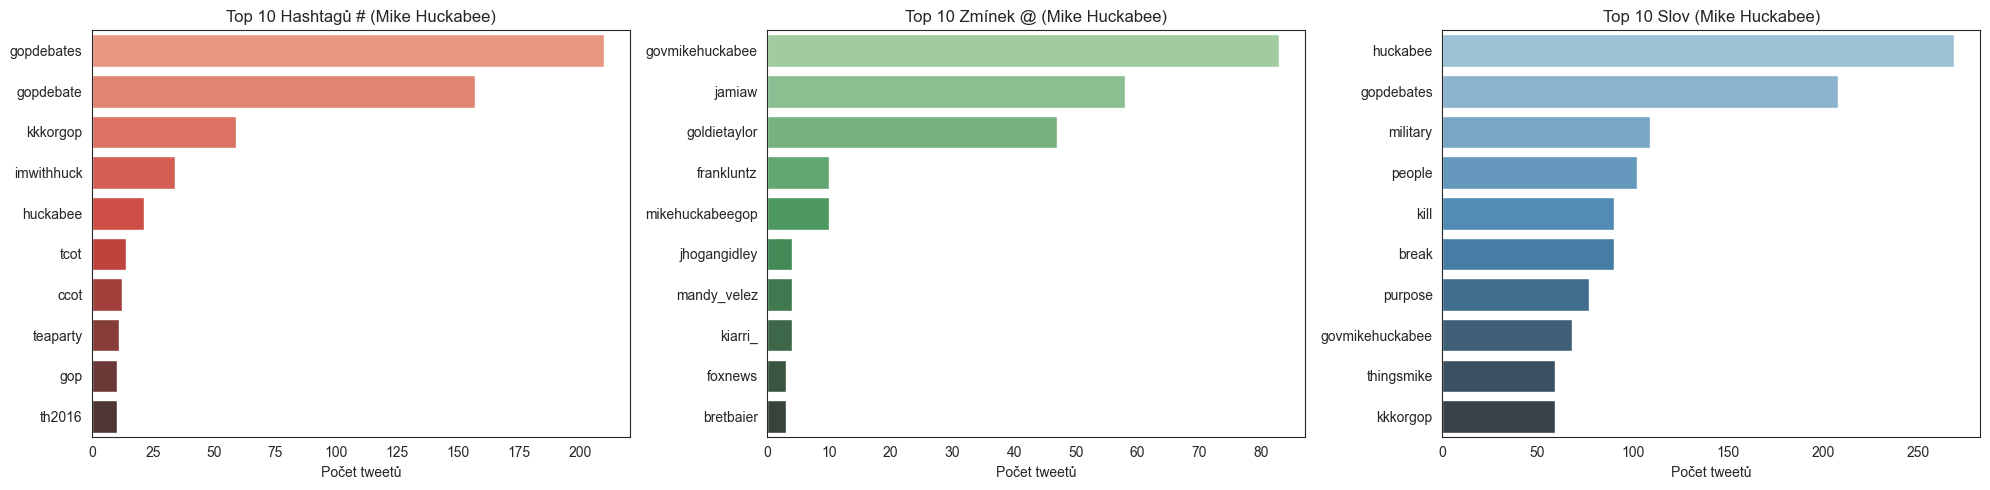


Concordance pro 'huckabee':
- ...best line night via govmike**huckabee** **huckabee** paying transgender surgery soldiers sailors...
- ...schtick candidates want reduce taxes **huckabee** wants legalize prostitution drugs tax...
- ...legalize prostitution drugs tax despite **huckabee** says always make sure prostitute...

Concordance pro 'gopdebates':
- ...huckabee prez smshow deray huckabeehulk **gopdebates** purpose military kill people break...
- ...kill people break thingsmike huckabee **gopdebates** kkkorgop reagan trust verify obama...
- ...trust vilify huckabee trust deepfry **gopdebates** tytlive purpose military kill people...

Concordance pro 'military':
- ...mosttweeted govmikehuckabee moment saying purpose **military** kill peoplebreak things trans servicemembers...
- ...focus group show spoke feedback **military** social experiment purpose **military** kill...
- ...feedback **military** social experiment purpose **military** kill people break things imwithhuck...

=======

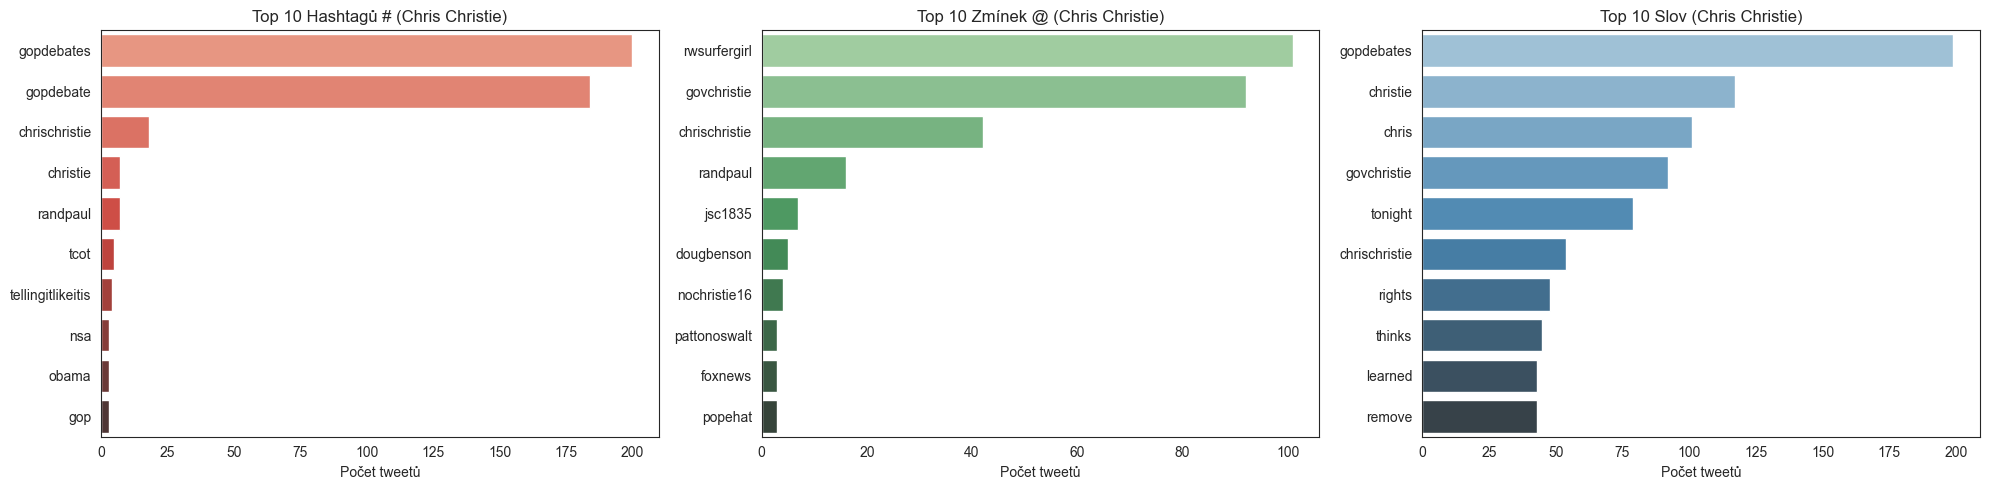


Concordance pro 'gopdebates':
- ...remove civil rights fight terrorism **gopdebates** fought teachers unionchrischristie improve new...
- ...remove civil rights fight terrorism **gopdebates** chris christie lips moving hes...
- ...hes still lying via sharethis **gopdebates** chrischristie elchubbo tonight learned govchristie...

Concordance pro 'christie':
- ...political gain rudygiulianigops thing chris **christie** really standing chris **christie** said...
- ...chris **christie** really standing chris **christie** said work two years retiringand...
- ...andy devine cant make chris **christie** stopped cleveland ice cream shop...

Concordance pro 'chris':
- ...tragedy political gain rudygiulianigops thing **chris** **chris**tie really standing **chris** **chris**tie...
- ...thing **chris** **chris**tie really standing **chris** **chris**tie said work two years...
- ...actor andy devine cant make **chris** **chris**tie stopped cleveland ice cream...

=================================

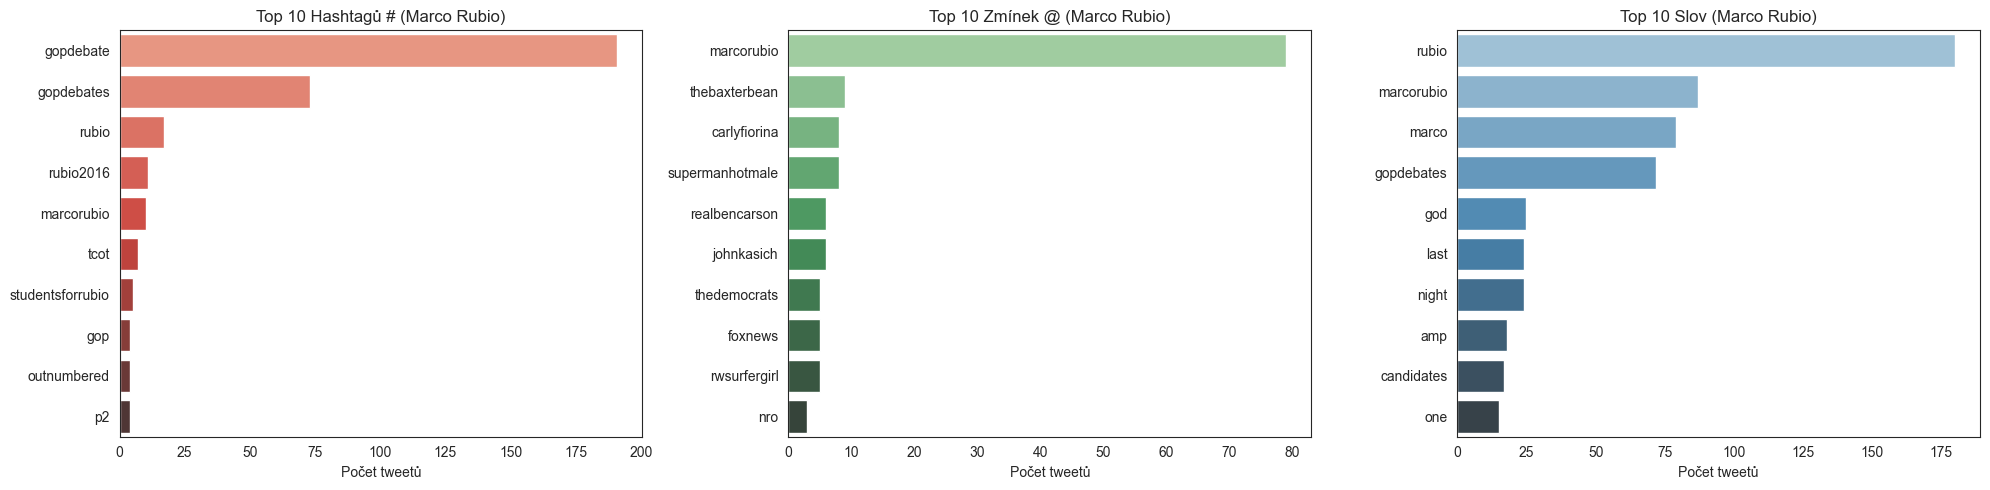


Concordance pro 'rubio':
- ...rankings worst performance **rubio** kasich christie bush trump cruz...
- ...walker paul huckabee carson marco **rubio** told face hes yesterday antigay...
- ...find one marco**rubio** republicans economics **rubio** wins bush falters huckabee exaggerates...

Concordance pro 'marcorubio':
- ...thedemocrats cant even find one **marcorubio** republicans economics rubio wins bush...
- ...deficit cuts investmenttax imho winners **marcorubio** kasich donaldtrump losers scottwalker randpaul...
- ...immigration reform privately berated dreamers **marcorubio** got best reviews deserved read...

Concordance pro 'marco':
- ...cruz walker paul huckabee carson **marco** rubio told face hes yesterday...
- ...falters huckabee exaggerates knowmorenotless gpnaplang **marco** nailed abortion must protect life...
- ...see point critics opportunism inconsistency **marco** rubio briefly backed immigration reform...

================================================ ANALÝZA KA

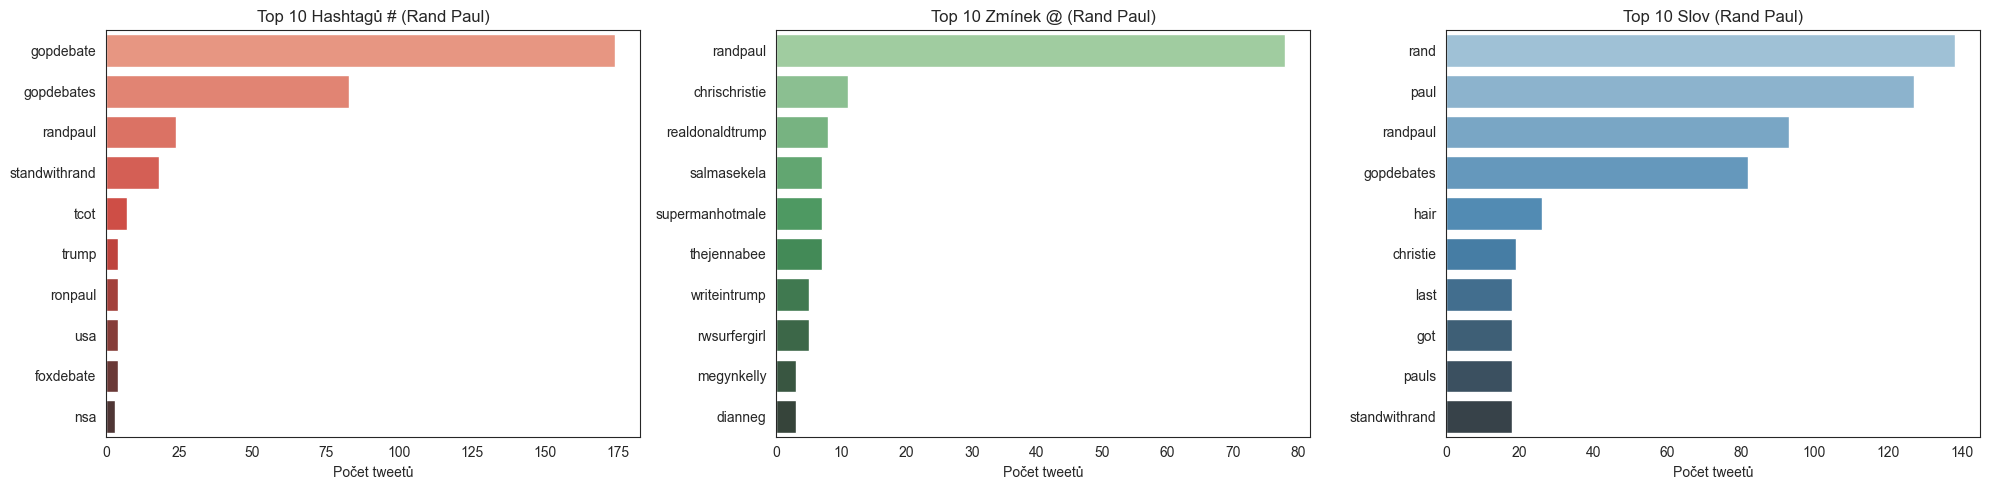


Concordance pro 'rand':
- ...realdonaldtrump reaction women question kellyfil **rand** paul eye roll chris christie...
- ...christie best moment last night **rand** telling christie get another hug...
- ...nothing lose nowhere anyway party **rand** paul couldnt get since bar...

Concordance pro 'paul':
- ...reaction women question kellyfil rand **paul** eye roll chris christie best...
- ...rand**paul** reiterating points realdonaldtrump andrand **paul** lands first haymaker night know...
- ...lose nowhere anyway party rand **paul** couldnt get since bar doesnt...

Concordance pro 'randpaul':
- ...chrisstirewalt big moments **randpaul** chrischristie realdonaldtrump reaction women question...
- ...wont bought amp wont sold **randpaul** reiterating points realdonaldtrump andrand paul...
- ...ooh killem contgopdebate losers rand **randpaul** combative mean realdonaldtrump fix biggest...

================================================ ANALÝZA KANDIDÁTA: Scott Walker ====================

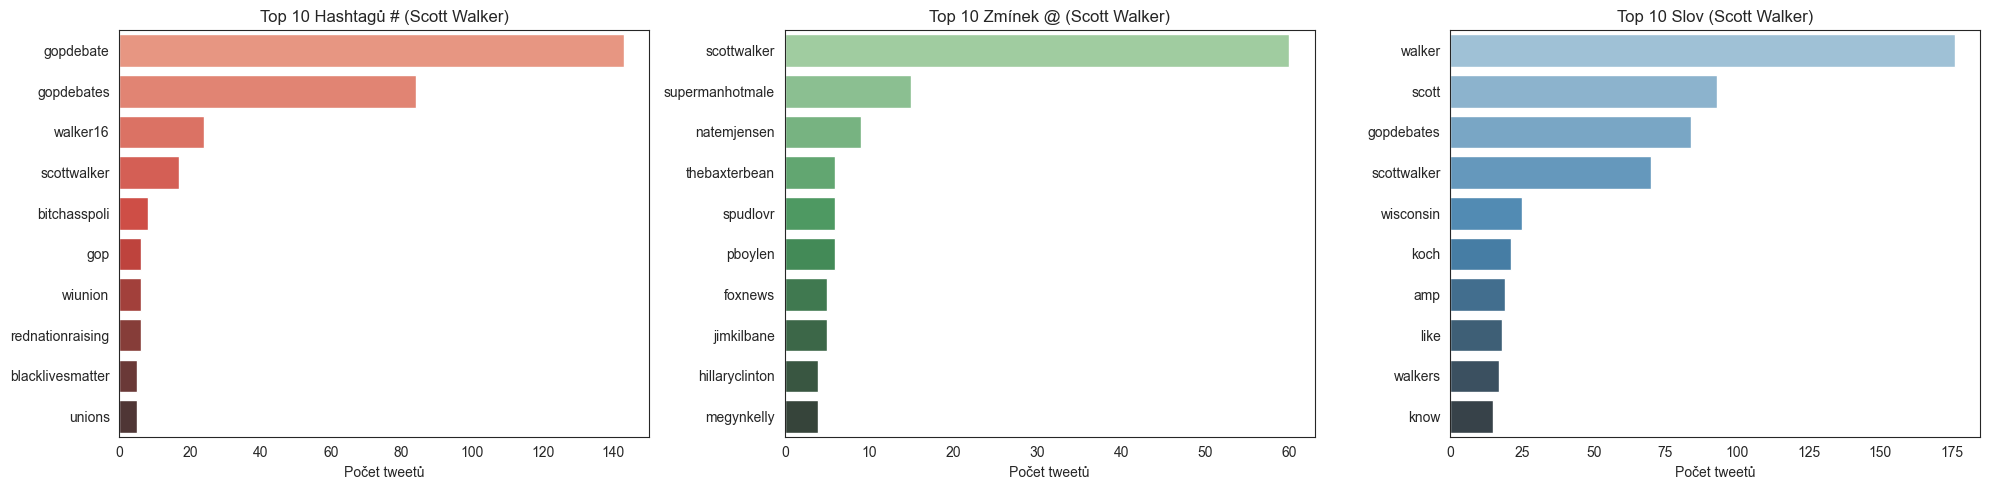


Concordance pro 'walker':
- ...night scotts best lines seconds **walker** loved scott **walker** mark harmons...
- ...lines seconds **walker** loved scott **walker** mark harmons romantic rival summer...
- ...sue emotional distress badger scott **walker** cant even carry state scott...

Concordance pro 'scott':
- ...best lines seconds walker loved **scott** walker mark harmons romantic rival...
- ...romantic rival summer school look **scott** walkers abortion ban allows rapist...
- ...father sue emotional distress badger **scott** walker cant even carry state...

Concordance pro 'gopdebates':
- ...leading run enterprise rentacar branch **gopdebates** walker emerges leading run enterprise...
- ...leading run enterprise rentacar branch **gopdebates** walker emerges leading run enterprise...
- ...leading run enterprise rentacar branch **gopdebates** walker emerges leading run enterprise...

================================================ ANALÝZA KANDIDÁTA: John Kasich ==================

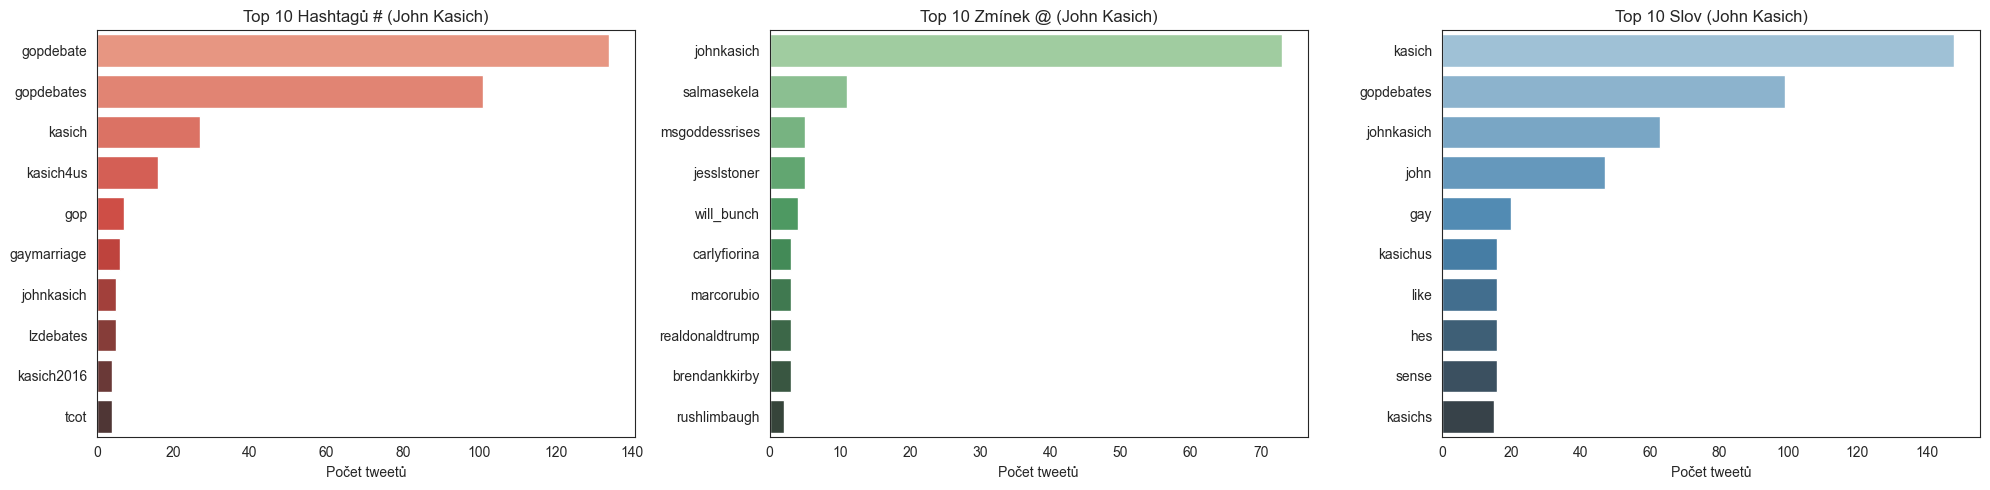


Concordance pro 'kasich':
- ...cant get nuke **kasich**us john **kasich** helped ohioans create new jobs...
- ...government payroll smaller decades john **kasich** ready lead join team claire...
- ...claire excited john**kasich** **kasich**us republicandebate **kasich** waiting years creating jobs greatest...

Concordance pro 'gopdebates':
- ...kasich spoke whole lot sense **gopdebates** hometown johnkasich gave touching answer...
- ...like reasonable human news johnsununu **gopdebates** johnkasich tells nhnews realdonaldtrump language...
- ...clearly arent presidential fitn medicaidworks **gopdebates** john kasich medicaids new spokesman...

Concordance pro 'johnkasich':
- ...lead join team claire excited **johnkasich** kasichus republicandebate kasich waiting years...
- ...guy shame hell drowned loonies **johnkasich** said hed love daughters gay...
- ...otherwise winners far concerned carlyfiorina **johnkasich** realbencarson marcorubio retrospect usa needs...


In [11]:
counts_df.columns = ['candidate','tweet_count']
collocations_shown = False
for candidate in candidates_to_process:
    print(f"\n{'='*48} ANALÝZA KANDIDÁTA: {candidate} {'='*48}")

    cand_words = df.loc[df['candidate'] == candidate, 'tokens_filtered'].sum()
    cand_hashtags = df.loc[df['candidate'] == candidate, 'hashtags'].sum()
    cand_mentions = df.loc[df['candidate'] == candidate, 'mentions'].sum()
    freq_dist = nltk.FreqDist(cand_words)
    freq_hashtags = nltk.FreqDist(cand_hashtags)
    freq_mentions = nltk.FreqDist(cand_mentions)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plot_top_items(freq_hashtags, f'Top 10 Hashtagů # ({candidate})', axes[0], 'Reds_d')
    plot_top_items(freq_mentions, f'Top 10 Zmínek @ ({candidate})', axes[1], 'Greens_d')
    plot_top_items(freq_dist, f'Top 10 Slov ({candidate})', axes[2], 'Blues_d')
    plt.tight_layout()
    plt.show()

    text_obj = nltk.Text(cand_words)
    if not cand_words or len(cand_words) == 0:
        print('Žádná tokenizovaná slova pro tohoto kandidáta.')
    else:
        top_words = [w for w, _ in freq_dist.most_common(3)]
        for word in top_words:
            print(f"\nConcordance pro '{word}':")
            indices = [i for i, t in enumerate(cand_words) if t == word]
            if not indices:
                print('Žádné výskyty')
            else:
                for idx in indices[:3]:
                    start = max(0, idx - 5)
                    end = min(len(cand_words), idx + 6)
                    context = ' '.join(cand_words[start:end])
                    highlighted = context.replace(word, f"**{word}**")
                    print(f"- ...{highlighted}...")

        if not collocations_shown:
            print('\nKolokace')
            text_obj.collocations()
            collocations_shown = True
    

In [12]:
print(f"{'='*48} PREDIKCE VOLEB {'='*48}")

print('\nPrůměrný sentiment kandidátů:')
mean_sentiments_df = mean_sentiments.reset_index()
mean_sentiments_df.columns = ['candidate','avg_vader_score']
print(mean_sentiments_df.to_string(index=False))

print('\nPočet tweetů podle kandidáta:')
counts_df = counts.reset_index()
counts_df.columns = ['candidate','tweet_count']
print(counts_df.to_string(index=False))


================================================ PREDIKCE VOLEB ================================================

Průměrný sentiment kandidátů:
             candidate  avg_vader_score
           John Kasich         0.201092
           Marco Rubio         0.195227
            Ben Carson         0.139694
          Donald Trump         0.065749
              Ted Cruz         0.050097
No candidate mentioned         0.049955
              Jeb Bush         0.016546
             Rand Paul         0.005128
        Chris Christie        -0.015785
          Scott Walker        -0.056845
         Mike Huckabee        -0.082205

Počet tweetů podle kandidáta:
             candidate  tweet_count
No candidate mentioned         7491
          Donald Trump         2813
              Jeb Bush          705
              Ted Cruz          637
            Ben Carson          404
         Mike Huckabee          393
        Chris Christie          293
           Marco Rubio          275
             Rand Pau

## Lze pouze na základě sentimentu predikovat výsledek voleb?

Na základě výstupních dat lze konstatovat, že nelze. V politické diskuzi na sociální síti Twitter je velmi obtížné pouze na základě sentimentu rozlišit například ironii a sarkasmus. Dataset tweetů není reprezantivním vzorkem reálných voličů a jejich reálného rozložení v populaci. V datasetu může být také obtížné odlišit přítomnost účtů botů nebo trollů a dalších statistiku zkreslujících parametrů.

V tomto datasetu by šla vyvodit zdánlivá závislost počtu tweetů na pravděpodobnosti zvolení. Donald Trump byl kandidátem s nějvětším počtem tweetů a byl celkovým vítězem voleb. Druhým v pořadí byl Ted Cruz, který byl zároveň třetím kandidátem s největším počtem tweetů. Z těchto výsledků by šlo pro tento dataset usoudit, že počet tweetů může být důležitým parametrem, který dokáže pomoci s předpovědí výsledků voleb a to bez ohledu na sentiment tweetů o daném kandidátovi.
